# # Notebook 02 — ResNet-18 Transfer Learning
# **DeepLense GSoC 2026 Evaluation**
# Fine-tune ImageNet-pretrained ResNet-18 on 3-channel 224×224 RGB images.
# Key upgrade over NB01: pre-trained weights + correct input resolution.

In [1]:
# %% [Cell 1: Mount Google Drive & Set Workspace]
import os, sys
 
from google.colab import drive
drive.mount('/content/drive')
 
BASE_DIR = "/content/drive/My Drive/DeepLense_GSoC_Data"
SRC_DIR  = os.path.join(BASE_DIR, "src")
 
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
 
print(f"✅ Workspace : {BASE_DIR}")
print(f"✅ src/ path : {SRC_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Workspace : /content/drive/My Drive/DeepLense_GSoC_Data
✅ src/ path : /content/drive/My Drive/DeepLense_GSoC_Data/src


In [2]:
# %% [Cell 2: WandB Authentication — Key loaded from .env file]
import os
import wandb
from dotenv import load_dotenv

load_dotenv(os.path.join(BASE_DIR, ".env"))
wandb.login(key=os.getenv("WANDB_API_KEY"))
print("✅ WandB authenticated successfully")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: diminiax (diminiax-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB authenticated successfully


In [3]:
# %% [Cell 3: Install Dependencies & Verify GPU]
# ── Install from pinned requirements — fixes numpy binary incompatibility ─
!pip install -q -r "/content/drive/My Drive/DeepLense_GSoC_Data/requirements.txt"

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device : {device}")
if device.type == 'cuda':
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")


🖥️  Device : cuda
   GPU    : Tesla T4


In [4]:
# %% [Cell 3: Imports & Reproducibility Seed]
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
 
from dataset import get_dataloaders, stage_data_locally
from models  import ResNetTransfer
from metrics import (
    save_confusion_matrix,
    generate_classification_report,
    plot_multiclass_roc_auc,
    plot_learning_curves,
)
 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
 
set_seed(42)
print("✅ Seed set to 42 — deterministic training enabled")

✅ Seed set to 42 — deterministic training enabled


In [ ]:
# %% [Cell 4: Stage Data & Build DataLoaders]
ZIP_PATH = os.path.join(BASE_DIR, "dataset.zip")
CSV_NAME = "metadata.csv"
 
# ── Stage data locally ────────────────────────────────────────────────────
staged_dir = stage_data_locally(ZIP_PATH)
data_dir   = staged_dir if staged_dir else BASE_DIR
csv_path   = os.path.join(data_dir, CSV_NAME)
 
print(f"📂 Data directory : {data_dir}")
print(f"📄 CSV path       : {csv_path}")
 
# ── Build DataLoaders ─────────────────────────────────────────────────────
# FIX v1: Image size upgraded 64×64 → 224×224
#         ImageNet weights expect large receptive fields — 64×64 was wrong
# FIX v1: val_transform is now SEPARATE (clean, no augmentation) — leakage fixed
# FIX v1: augment=False here — augmentation is isolated to Notebook 03
# FIX v2: get_dataloaders now returns a 6-tuple (adds test_loader + test_df)
train_loader, val_loader, _, train_df, val_df, _ = get_dataloaders(
    csv_path   = csv_path,
    base_dir   = data_dir,
    mode       = 'RGB',     # 3-channel — required for ImageNet pre-trained weights
    image_size = 224,       # FIX: was 64 in v1 — ImageNet weights need 224×224
    batch_size = 32,
    augment    = False,     # Clean transfer learning baseline — no augmentation
)
 
print(f"\n✅ Train batches : {len(train_loader)} ({len(train_df)} images)")
print(f"✅ Val batches   : {len(val_loader)}   ({len(val_df)} images)")

✅ Local staging already complete at: /content/local_dataset
📂 Data directory : /content/local_dataset
📄 CSV path       : /content/local_dataset/metadata.csv

📊 Dataset Class Distribution:
   cdm        :   500 samples  (33.3%)
   no_sub     :   500 samples  (33.3%)
   vortex     :   500 samples  (33.3%)
   TOTAL      :  1500 samples

✅ Split — Train: 1050 | Val: 225 | Test: 225

✅ Train batches : 32 (1050 images)
✅ Val batches   : 8   (225 images)


In [6]:
# %% [Cell 5: Model, Loss, Optimizer, Scheduler]
# ── Model ─────────────────────────────────────────────────────────────────
# ResNetTransfer loads ImageNet weights and replaces the 1000-class head
# with a 3-class head. All layers are unfrozen for full fine-tuning.
model = ResNetTransfer(num_classes=3, freeze_backbone=False).to(device)
print(f"🧠 Model      : ResNetTransfer (ImageNet weights)")
print(f"   Input      : (B, 3, 224, 224) — RGB, ImageNet-normalised")
print(f"   Output     : (B, 3) — logits for [no_sub, cdm, vortex]")
print(f"   Strategy   : Full fine-tuning (all layers unfrozen)")
 
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Total params    : {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")
 
# ── Loss ──────────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
 
# ── Optimizer ─────────────────────────────────────────────────────────────
# Low LR (1e-4) is critical for fine-tuning.
# Too high → catastrophic forgetting of ImageNet feature extractors.
# Too low  → slow convergence on the new domain.
LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
 
# ── LR Scheduler ─────────────────────────────────────────────────────────
# CosineAnnealingLR: smoothly decays LR from 1e-4 to near-zero over all epochs.
# Prevents oscillation around the optimum in the final epochs.
EPOCHS    = 10
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)
 
print(f"\n⚙️  Optimizer  : Adam (lr={LEARNING_RATE})")
print(f"⚙️  Scheduler  : CosineAnnealingLR (T_max={EPOCHS})")
print(f"⚙️  Epochs     : {EPOCHS}")
 
ASSETS_DIR  = os.path.join(BASE_DIR, "assets")
WEIGHTS_DIR = os.path.join(BASE_DIR, "weights")
os.makedirs(ASSETS_DIR,  exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


🧠 Model      : ResNetTransfer (ImageNet weights)
   Input      : (B, 3, 224, 224) — RGB, ImageNet-normalised
   Output     : (B, 3) — logits for [no_sub, cdm, vortex]
   Strategy   : Full fine-tuning (all layers unfrozen)
   Total params    : 11,178,051
   Trainable params: 11,178,051

⚙️  Optimizer  : Adam (lr=0.0001)
⚙️  Scheduler  : CosineAnnealingLR (T_max=10)
⚙️  Epochs     : 10


In [7]:
# %% [Cell 6: Training Loop]
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
 
best_val_acc = 0.0
best_epoch   = 0
best_weights = None
 
print(f"🚀 Starting Transfer Learning — {EPOCHS} epochs\n")
 
for epoch in range(EPOCHS):
 
    # ── TRAIN ─────────────────────────────────────────────────────────────
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
 
    pbar = tqdm(train_loader, desc=f"  Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
 
        optimizer.zero_grad()
        logits = model(images)               # (B, 3) raw logits
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
 
        t_loss    += loss.item()
        _, preds   = torch.max(logits, 1)
        t_total   += labels.size(0)
        t_correct += (preds == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100*t_correct/t_total:.1f}%")
 
    train_loss = t_loss / len(train_loader)
    train_acc  = 100.0 * t_correct / t_total
 
    # ── VALIDATE ──────────────────────────────────────────────────────────
    # FIX v1: Validation now runs every epoch with CLEAN val_transform
    # val_loader uses get_val_transform() — zero augmentation, deterministic
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
 
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits  = model(images)
            v_loss    += criterion(logits, labels).item()
            _, preds   = torch.max(logits, 1)
            v_total   += labels.size(0)
            v_correct += (preds == labels).sum().item()
 
    val_loss = v_loss / len(val_loader)
    val_acc  = 100.0 * v_correct / v_total
 
    # ── Scheduler step ────────────────────────────────────────────────────
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
 
    # ── Record history ────────────────────────────────────────────────────
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
 
    # ── Best checkpoint ───────────────────────────────────────────────────
    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(best_weights, os.path.join(WEIGHTS_DIR, "transfer_best.pth"))
 
    print(
        f"  Epoch {epoch+1:>2}/{EPOCHS} │ "
        f"Train  loss={train_loss:.4f}  acc={train_acc:.1f}% │ "
        f"Val  loss={val_loss:.4f}  acc={val_acc:.1f}% │ "
        f"LR={current_lr:.2e}"
        + (" ✅ best" if is_best else "")
    )
 
torch.save(model.state_dict(), os.path.join(WEIGHTS_DIR, "transfer_final.pth"))
print(f"\n💾 Final weights → weights/transfer_final.pth")
print(f"💾 Best weights  → weights/transfer_best.pth  (epoch {best_epoch}, val_acc={best_val_acc:.1f}%)")

🚀 Starting Transfer Learning — 10 epochs



  Epoch  1/10 │ Train  loss=0.8276  acc=61.9% │ Val  loss=0.8000  acc=65.3% │ LR=9.76e-05 ✅ best


  Epoch  2/10 │ Train  loss=0.5767  acc=77.0% │ Val  loss=1.4256  acc=64.9% │ LR=9.05e-05


  Epoch  3/10 │ Train  loss=0.4950  acc=79.4% │ Val  loss=0.8511  acc=77.3% │ LR=7.94e-05 ✅ best


  Epoch  4/10 │ Train  loss=0.3638  acc=85.3% │ Val  loss=0.6075  acc=80.4% │ LR=6.55e-05 ✅ best


...

  Epoch  6/10 │ Train  loss=0.1934  acc=93.0% │ Val  loss=0.4212  acc=79.1% │ LR=3.46e-05


  Epoch  7/10 │ Train  loss=0.1069  acc=97.4% │ Val  loss=0.4075  acc=84.0% │ LR=2.07e-05 ✅ best


  Epoch  8/10 │ Train  loss=0.0572  acc=99.1% │ Val  loss=0.2893  acc=89.3% │ LR=9.64e-06 ✅ best


  Epoch  9/10 │ Train  loss=0.0446  acc=99.5% │ Val  loss=0.3160  acc=88.0% │ LR=2.54e-06


  Epoch 10/10 │ Train  loss=0.0315  acc=99.9% │ Val  loss=0.3138  acc=87.1% │ LR=1.00e-07

💾 Final weights → weights/transfer_final.pth
💾 Best weights  → weights/transfer_best.pth  (epoch 8, val_acc=89.3%)


📊 Learning curves saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/transfer_learning_curves.png


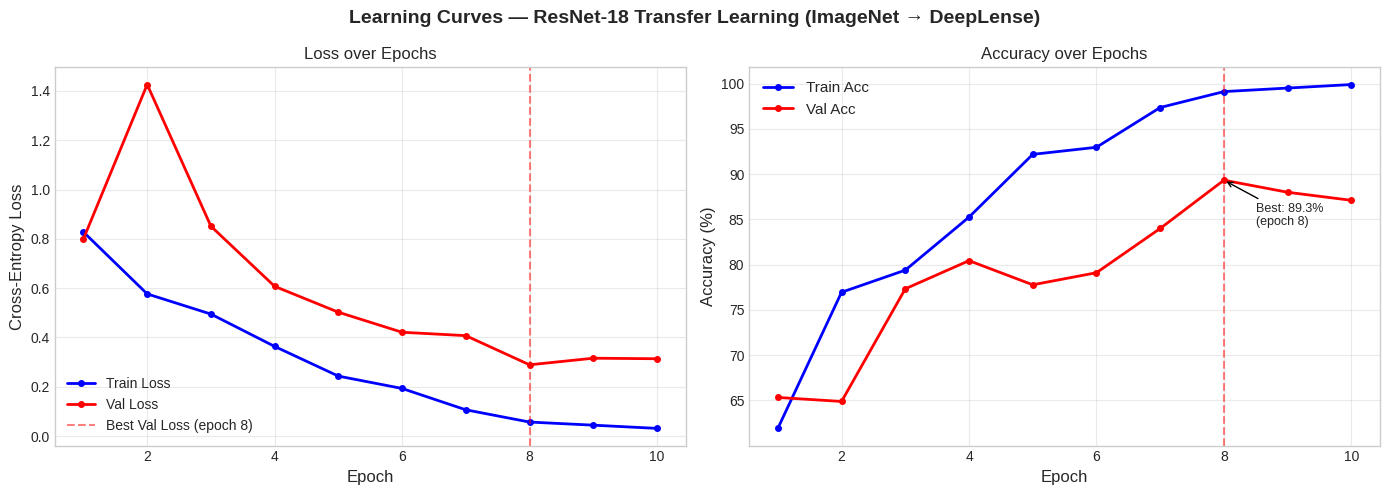

In [8]:
# %% [Cell 7: Learning Curves Plot]
plot_learning_curves(
    train_losses = train_losses,
    val_losses   = val_losses,
    train_accs   = train_accs,
    val_accs     = val_accs,
    save_path    = os.path.join(ASSETS_DIR, "transfer_learning_curves.png"),
    model_name   = "ResNet-18 Transfer Learning (ImageNet → DeepLense)",
)

In [9]:
# %% [Cell 8: Evaluation — Restore Weights & Run Inference]
# Load best weights directly from Drive — skip retraining
model.load_state_dict(
    torch.load(os.path.join(WEIGHTS_DIR, "transfer_best.pth"), map_location=device)
)
model.eval()
 
all_preds  = []
all_labels = []
all_probs  = []
 
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        probs  = F.softmax(logits, dim=1)
 
        _, preds = torch.max(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
 
all_probs = np.array(all_probs)
CLASSES   = ['No Sub', 'CDM', 'Vortex']
 
# FIX v2: Capture return dict so f1_macro flows into TRANSFER_RESULTS
report = generate_classification_report(
    all_labels, all_preds,
    classes    = CLASSES,
    model_name = "ResNet-18 Transfer Learning",
)


  CLASSIFICATION REPORT  —  ResNet-18 Transfer Learning
              precision    recall  f1-score   support

      No Sub     0.9259    1.0000    0.9615        75
         CDM     0.8493    0.8267    0.8378        75
      Vortex     0.9014    0.8533    0.8767        75

    accuracy                         0.8933       225
   macro avg     0.8922    0.8933    0.8920       225
weighted avg     0.8922    0.8933    0.8920       225

  Macro F1        : 0.8920  ← use in result dicts
  Weighted F1     : 0.8920
  Macro Precision : 0.8922
  Macro Recall    : 0.8933



📊 Confusion matrix saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/transfer_confusion_matrix.png


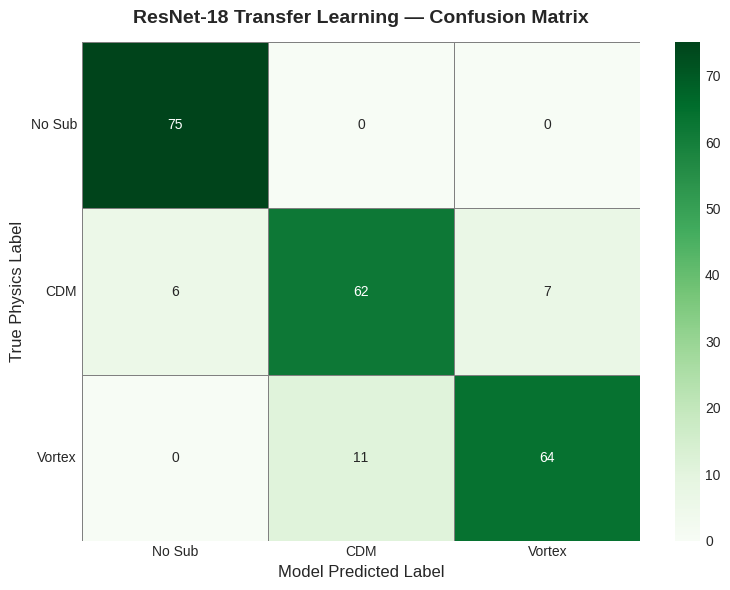


  ROC-AUC & PHYSICS REPORT  —  ResNet-18 Transfer Learning (ImageNet → DeepLense)
  No Sub      : AUC = 0.9935  |  FPR @ 90% TPR = 0.0200
  CDM         : AUC = 0.9396  |  FPR @ 90% TPR = 0.2533
  Vortex      : AUC = 0.9725  |  FPR @ 90% TPR = 0.0467
  -------------------------------------------------------------
  Micro-Avg   : AUC = 0.9741  |  FPR @ 90% TPR = 0.0556
  Macro-Avg   : AUC = 0.9686  |  FPR @ 90% TPR = 0.1067

📊 ROC curve saved → /content/drive/My Drive/DeepLense_GSoC_Data/assets/transfer_roc_auc.png


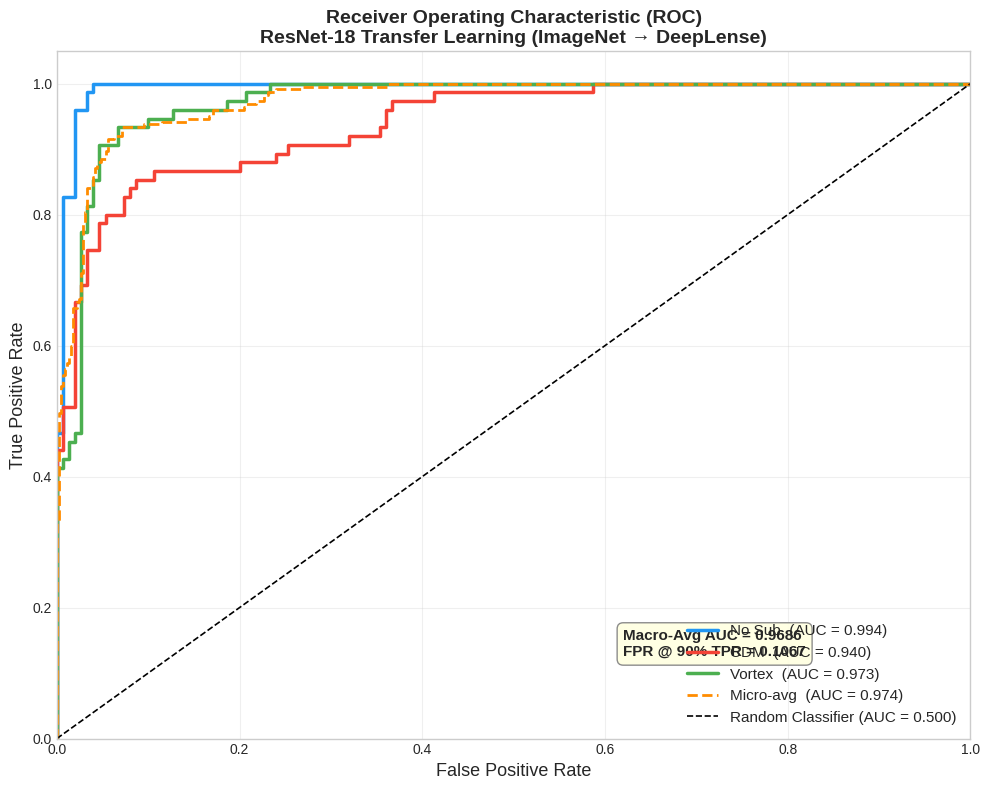

In [10]:
# %% [Cell 9: Confusion Matrix & ROC-AUC Plots]
save_confusion_matrix(
    all_labels, all_preds,
    classes   = CLASSES,
    save_path = os.path.join(ASSETS_DIR, "transfer_confusion_matrix.png"),
    title     = "ResNet-18 Transfer Learning — Confusion Matrix",
    cmap      = "Greens",
)
 
# FIX v1: ROC-AUC was completely missing for Transfer Learning model
auc_scores = plot_multiclass_roc_auc(
    all_labels, all_probs,
    classes    = CLASSES,
    save_path  = os.path.join(ASSETS_DIR, "transfer_roc_auc.png"),
    model_name = "ResNet-18 Transfer Learning (ImageNet → DeepLense)",
)

In [ ]:
# %% [Cell 10: Results Dict — Paste into Notebook 06]
# Store for Notebook 06 comparison table
TRANSFER_RESULTS = {
    'model':        'ResNet-18 Transfer',
    'val_acc':      best_val_acc,
    'macro_auc':    auc_scores['macro'],
    'cdm_auc':      auc_scores['per_class'][1],
    'fpr_90_macro': auc_scores['fpr_90_macro'],
    'f1_macro':     report['f1_macro'],   # FIX v2: was hardcoded 0.0
}
 
print("\n📌 TRANSFER_RESULTS (paste into Notebook 06):")
print(TRANSFER_RESULTS)
 


📌 TRANSFER_RESULTS (paste into Notebook 06):
{'model': 'ResNet-18 Transfer', 'val_acc': 89.33333333333333, 'macro_auc': 0.968562962962963, 'cdm_auc': 0.9396444444444445, 'fpr_90_macro': 0.10666666666666669, 'f1_macro': 0.8920295427144742}


In [12]:
# %% [Cell 10: Save Results to JSON — feeds NB06 automatically]
import json

RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

with open(os.path.join(RESULTS_DIR, "transfer_results.json"), "w") as f:
    json.dump(TRANSFER_RESULTS, f, indent=2)

print("💾 Results saved → results/transfer_results.json")

💾 Results saved → results/transfer_results.json
